# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

Виконав: Горбачов Олег, ВТ-23-1


## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [2]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [3]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)
if not IN_COLAB:
    print("Попередження: не Colab, продовжуємо локально (для здачі треба прогнати в Colab)")


Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [4]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі ПІСЛЯ, викликаючи `set_seed()`. Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [5]:
numbers = list(range(10))  # список для shuffle

# ДО set_seed() -- результати різні при кожному запуску
print("ДО 1:", random.randint(1, 100))
tmp = numbers.copy(); random.shuffle(tmp); print("ДО shuffle 1:", tmp)
print("ДО 2:", random.randint(1, 100))
tmp = numbers.copy(); random.shuffle(tmp); print("ДО shuffle 2:", tmp)

set_seed()
print("Seed зафіксовано:", SEED)

# ПІСЛЯ -- set_seed() перед КОЖНИМ генеруванням -> результати однакові
set_seed(); print("ПІСЛЯ 1:", random.randint(1, 100))
set_seed(); tmp = numbers.copy(); random.shuffle(tmp); print("ПІСЛЯ shuffle 1:", tmp)
set_seed(); print("ПІСЛЯ 2:", random.randint(1, 100))
set_seed(); tmp = numbers.copy(); random.shuffle(tmp); print("ПІСЛЯ shuffle 2:", tmp)


ДО 1: 5
ДО shuffle 1: [0, 3, 9, 4, 8, 1, 6, 7, 2, 5]
ДО 2: 80
ДО shuffle 2: [7, 9, 2, 5, 8, 1, 4, 3, 0, 6]
Seed зафіксовано: 42
ПІСЛЯ 1: 82
ПІСЛЯ shuffle 1: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
ПІСЛЯ 2: 82
ПІСЛЯ shuffle 2: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]


Я запускав randint і shuffle по два рази до set_seed() — числа і порядок виходили різні щоразу. Після set_seed(42) все стало повторюватись один в один, якщо викликати set_seed() перед кожним разом. Тобто сід просто ставить генератор в одну й ту саму початкову точку, і далі все псевдовипадкове йде по колу однаково. Зручно, бо тоді і дані, і навчання виходять відтворювані.

### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [6]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [7]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"
except Exception as e:
    print("Не в Colab або Drive недоступний, використовуємо локальну папку:", e)
    ARTIFACT_DIR = os.path.join(os.getcwd(), "lab1", "artifacts_local")

os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Не в Colab або Drive недоступний, використовуємо локальну папку: Error: credential propagation was unsuccessful
Артефакти зберігаються в: /content/lab1/artifacts_local


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [8]:
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print("zeros:", zeros_arr.shape, zeros_arr.dtype)
print(zeros_arr)
print("sevens:", sevens_arr.shape, sevens_arr.dtype)
print(sevens_arr)


zeros: (3, 4) float64
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
sevens: (3, 4) int64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]]


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [9]:
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [10]:
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print(identity)
print(random_ints)
print("ndim identity:", identity.ndim)
print("ndim random_ints:", random_ints.ndim)


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[6 3 7]
 [4 6 9]
 [2 6 7]]
ndim identity: 2
ndim random_ints: 2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [11]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

mean = scores.mean()
std = scores.std()
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [12]:
arr = np.arange(1, 13)

matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [13]:
df = pd.DataFrame({"name": ["Олег", "Катя", "Діма", "Настя", "Тарас"],
                    "score": [78, 92, 65, 88, 95]})
# беру тих в кого більше 80 і сортую від кращого
top = df[df["score"] > 80].sort_values("score", ascending=False)
print(top)


    name  score
4  Тарас     95
1   Катя     92
3  Настя     88


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [14]:
# розставляю оцінки: від 90 - А, від 75 - В, решта - С
df["grade"] = np.where(df["score"] >= 90, "A", np.where(df["score"] >= 75, "B", "C"))
print(df)


    name  score grade
0   Олег     78     B
1   Катя     92     A
2   Діма     65     C
3  Настя     88     B
4  Тарас     95     A


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [15]:
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)

print(zeros_t)
print(sevens_t)
print("zeros:", zeros_t.shape, zeros_t.dtype)
print("sevens:", sevens_t.shape, sevens_t.dtype)


tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[7, 7, 7],
        [7, 7, 7]])
zeros: torch.Size([2, 3]) torch.float32
sevens: torch.Size([2, 3]) torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [16]:
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [17]:
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list)
print(random_t)
print("from_list:", from_list.shape, from_list.dtype, from_list.ndim)
print("random_t:", random_t.shape, random_t.dtype, random_t.ndim)


tensor([[1, 2],
        [3, 4]])
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])
from_list: torch.Size([2, 2]) torch.int64 2
random_t: torch.Size([3, 3]) torch.float32 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [18]:
n = 5.0

x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()
print("autograd dy/dx:", x.grad.item(), " аналітично 2*n:", 2 * n)


autograd dy/dx: 10.0  аналітично 2*n: 10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [19]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for _ in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()
    with torch.no_grad():
        x -= lr * x.grad
    x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

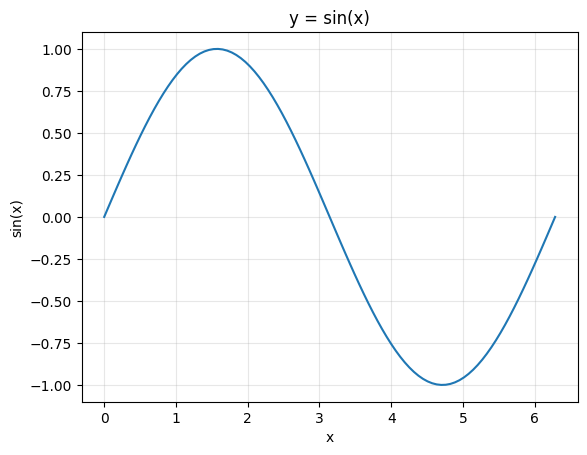

In [20]:
xs = np.linspace(0, 2*np.pi, 100)
plt.plot(xs, np.sin(xs))
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("y = sin(x)")
plt.grid(alpha=0.3)
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

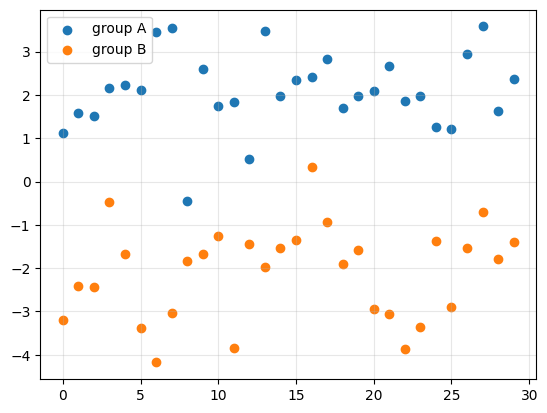

In [21]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

plt.scatter(range(len(group_a)), group_a, color="C0", label="group A")
plt.scatter(range(len(group_b)), group_b, color="C1", label="group B")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [22]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

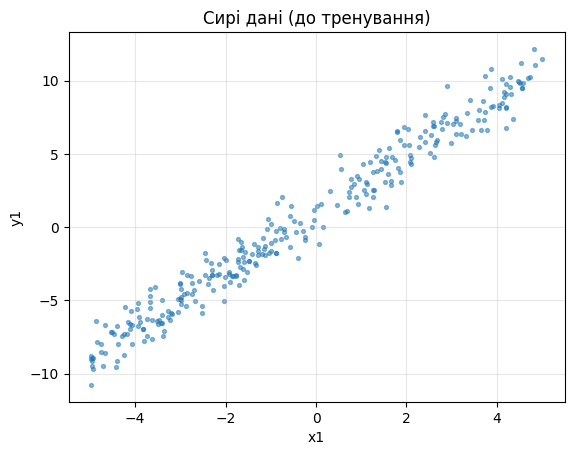

In [23]:
plt.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.5)
plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")
plt.grid(alpha=0.3)
plt.show()


**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [24]:
set_seed()
perm = torch.randperm(TASK1_N)
x1, y1 = x1[perm], y1[perm]
n_train = int(0.7 * TASK1_N)
n_val = int(0.15 * TASK1_N)
x_train1, y_train1 = x1[:n_train], y1[:n_train]
x_val1, y_val1 = x1[n_train:n_train+n_val], y1[n_train:n_train+n_val]
x_test1, y_test1 = x1[n_train+n_val:], y1[n_train+n_val:]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [25]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=43.316730  w=1.5235 (true 2.0)  b=0.0181 (true 1.0)
epoch   30  loss=1.000557  w=1.9719 (true 2.0)  b=0.9505 (true 1.0)
epoch   60  loss=0.997888  w=1.9749 (true 2.0)  b=0.9956 (true 1.0)
epoch   90  loss=0.997882  w=1.9750 (true 2.0)  b=0.9978 (true 1.0)
epoch   99  loss=0.997882  w=1.9750 (true 2.0)  b=0.9978 (true 1.0)


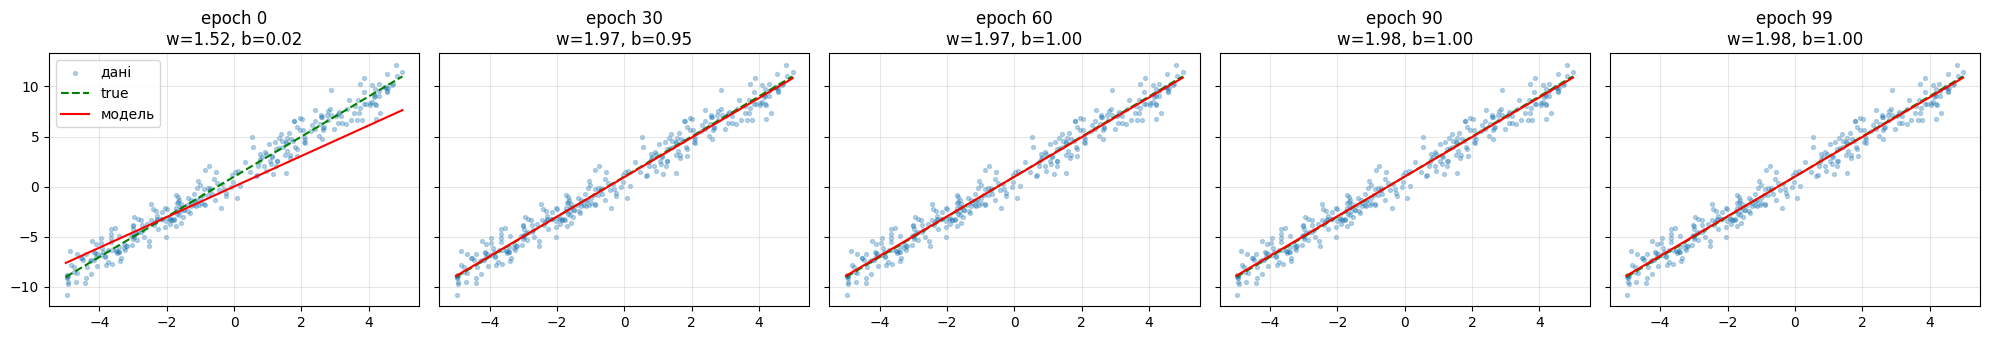

In [26]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

### Мій сценарій (вправа 20)
Взяв те що сам бачу кожну сесію: скільки годин готувався — такий і бал. Поставив y = 8x + 45: без підготовки можна десь на 45 вгадати тест, а кожна година дає приблизно +8. Годин брав від 0 до 7, бо більше 7 в день я все одно не сиджу. Шум 3 додав, бо варіанти різні попадаються.

CSV: /content/lab1/artifacts_local/dataset.csv (300, 2)
      hours      score
0  6.175885  92.735512
1  6.405028  93.335175
2  2.680046  69.054207
3  6.715139  98.434189
4  2.733138  68.076508
w=8.14 (true 8.0), b=44.62 (true 45.0)
train=7.847 val=10.123 test=10.853


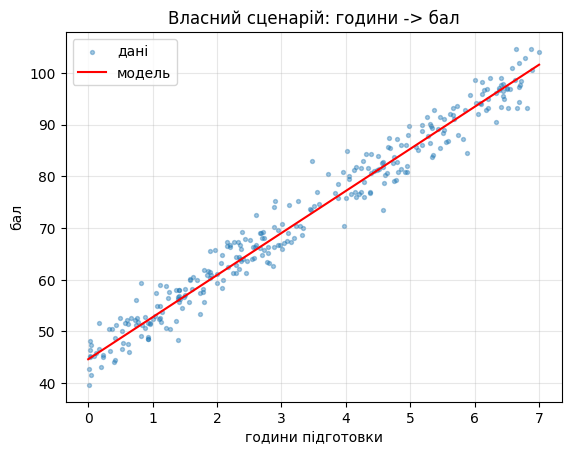

In [27]:
# --- Вправа 20: власні дані + перевикористовувані функції ---
set_seed()
TRUE_W, TRUE_B = 8.0, 45.0
N = 300
hours = torch.empty(N, 1).uniform_(0, 7)
scores_y = TRUE_W * hours + TRUE_B + 3.0 * torch.randn(N, 1)

df_my = pd.DataFrame({"hours": hours.squeeze(1).numpy(), "score": scores_y.squeeze(1).numpy()})
csv_path = os.path.join(ARTIFACT_DIR, "dataset.csv")
df_my.to_csv(csv_path, index=False)
# копія поруч із ноутбуком для здачі на GitHub
os.makedirs("lab1", exist_ok=True)
df_my.to_csv("lab1/dataset.csv", index=False)
print("CSV:", csv_path, df_my.shape)
print(df_my.head())

def make_split(x, y, train=0.7, val=0.15):
    perm = torch.randperm(len(x))
    x, y = x[perm], y[perm]
    n_tr, n_v = int(len(x)*train), int(len(x)*val)
    return (x[:n_tr], y[:n_tr]), (x[n_tr:n_tr+n_v], y[n_tr:n_tr+n_v]), (x[n_tr+n_v:], y[n_tr+n_v:])

def train_linear(x_tr, y_tr, lr=0.05, epochs=200):
    model = torch.nn.Linear(1, 1)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()
    for ep in range(epochs):
        opt.zero_grad()
        loss = loss_fn(model(x_tr), y_tr)
        loss.backward(); opt.step()
    return model

def eval_mse(model, x, y):
    with torch.no_grad():
        return torch.nn.MSELoss()(model(x), y).item()

(train_x, train_y), (val_x, val_y), (test_x, test_y) = make_split(hours, scores_y)
my_model = train_linear(train_x, train_y)
print(f"w={my_model.weight.item():.2f} (true {TRUE_W}), b={my_model.bias.item():.2f} (true {TRUE_B})")
print(f"train={eval_mse(my_model, train_x, train_y):.3f} val={eval_mse(my_model, val_x, val_y):.3f} test={eval_mse(my_model, test_x, test_y):.3f}")

plt.scatter(hours.numpy(), scores_y.numpy(), s=8, alpha=0.4, label='дані')
with torch.no_grad():
    xs_l = torch.linspace(0, 7, 100).unsqueeze(1)
    plt.plot(xs_l.numpy(), my_model(xs_l).numpy(), 'r-', label='модель')
plt.xlabel("години підготовки"); plt.ylabel("бал")
plt.title("Власний сценарій: години -> бал")
plt.legend(); plt.grid(alpha=0.3); plt.show()


In [28]:
# --- Вправа 21: збереження моделі ---
torch.save(my_model.state_dict(), os.path.join(ARTIFACT_DIR, "model.pt"))
os.makedirs("lab1", exist_ok=True)
torch.save(my_model.state_dict(), "lab1/model.pt")
print("Збережено model.pt")


Збережено model.pt


In [29]:
# --- Вправа 22: Gradio (запускати тільки в Colab) ---
!pip install -q gradio
import gradio as gr

loaded = torch.nn.Linear(1, 1)
loaded.load_state_dict(torch.load(os.path.join(ARTIFACT_DIR, 'model.pt'), map_location='cpu'))
loaded.eval()

def predict(hours_in):
    with torch.no_grad():
        return float(loaded(torch.tensor([[float(hours_in)]])).item())

gr.Interface(fn=predict, inputs=gr.Slider(0, 7, step=0.5, label="Годин підготовки"), outputs=gr.Number(label="Прогноз балу")).launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7acd5a3fed77880997.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```